<a href="https://colab.research.google.com/github/MuhammadRibhiRamadan/fsi-prediction-id/blob/main/DSAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Machine Learning-Based Prediction of Food Security Index Using Food Prices and Socioeconomic Indicators in Indonesia**

In [ ]:
!ls

drive  sample_data


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.preprocessing as sk

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Data Sources and Collection**

World Bank (WB)

In [ ]:
food = pd.read_csv('/content/drive/MyDrive/ProjectDSAI/IDN_RTFP_mkt_2007_2026-04-08.csv')

Food Security and Vulnerability Atlas (FSVA)

In [ ]:
years = [2020, 2021, 2022, 2023, 2024, 2025]
dfs_fsva = []

for year in years:
    file = f'/content/drive/MyDrive/ProjectDSAI/tabel_data ({year}).csv'
    temp = pd.read_csv(file)
    temp['year'] = year
    dfs_fsva.append(temp)

Badan Pusat Statistik (BPS)

In [ ]:
years = [2020, 2021, 2022, 2023, 2024, 2025]
dfs_bps = []

for year in years:
    file = f"/content/drive/MyDrive/ProjectDSAI/Jumlah dan Persentase Penduduk Miskin Menurut Provinsi, {year}.csv"
    temp = pd.read_csv(file)
    temp['year'] = year
    dfs_bps.append(temp)

# **Data Preprocessing**

Food Prices (WB)

In [9]:
food.head()
food.columns

Index(['ISO3', 'country', 'adm1_name', 'adm2_name', 'mkt_name', 'lat', 'lon',
       'geo_id', 'price_date', 'year', 'month', 'currency', 'components',
       'start_dense_data', 'last_survey_point', 'data_coverage',
       'data_coverage_recent', 'index_confidence_score',
       'spatially_interpolated', 'chili', 'eggs', 'garlic', 'meat_beef',
       'meat_chicken', 'meat_chicken_broiler', 'oil', 'onions', 'rice',
       'sugar', 'o_chili', 'h_chili', 'l_chili', 'c_chili', 'inflation_chili',
       'trust_chili', 'o_eggs', 'h_eggs', 'l_eggs', 'c_eggs', 'inflation_eggs',
       'trust_eggs', 'o_garlic', 'h_garlic', 'l_garlic', 'c_garlic',
       'inflation_garlic', 'trust_garlic', 'o_meat_beef', 'h_meat_beef',
       'l_meat_beef', 'c_meat_beef', 'inflation_meat_beef', 'trust_meat_beef',
       'o_meat_chicken', 'h_meat_chicken', 'l_meat_chicken', 'c_meat_chicken',
       'inflation_meat_chicken', 'trust_meat_chicken',
       'o_meat_chicken_broiler', 'h_meat_chicken_broiler',
       '

only select the year from 2020 to 2025

In [10]:
food['price_date'] = pd.to_datetime(food['price_date'])
food['year'] = food['price_date'].dt.year
food = food[food['year'].between(2020,2025)]

sorted(food['year'].dropna().unique())

[np.int32(2020),
 np.int32(2021),
 np.int32(2022),
 np.int32(2023),
 np.int32(2024),
 np.int32(2025)]

In [ ]:
food['year'].value_counts().sort_index()

,count
year,
2020,2676
2021,2676
2022,2676
2023,2676
2024,2676
2025,2676


In [ ]:
food_prov = food[food['adm1_name'] != 'Market Average']

food_prov['year'].value_counts().sort_index()

,count
year,
2020,2664
2021,2664
2022,2664
2023,2664
2024,2664
2025,2664


In [ ]:
food_prov['adm1_name'].unique()

array(['SULAWESI UTARA', 'SUMATERA UTARA', 'KALIMANTAN UTARA',
       'JAWA BARAT', 'NUSA TENGGARA BARAT', 'NUSA TENGGARA TIMUR',
       'SULAWESI SELATAN', 'JAMBI', 'JAWA TIMUR', 'KALIMANTAN SELATAN',
       'BALI', 'BANTEN', 'JAWA TENGAH', 'RIAU', 'SUMATERA BARAT',
       'KEPULAUAN RIAU', 'PAPUA', 'SULAWESI BARAT', 'BENGKULU',
       'MALUKU UTARA', 'DAERAH ISTIMEWA YOGYAKARTA', 'KALIMANTAN BARAT',
       'KALIMANTAN TENGAH', 'PAPUA BARAT', 'SUMATERA SELATAN', 'MALUKU',
       'KEPULAUAN BANGKA BELITUNG', 'ACEH', 'DKI JAKARTA',
       'SULAWESI TENGGARA', 'GORONTALO', 'KALIMANTAN TIMUR', 'LAMPUNG',
       'SULAWESI TENGAH'], dtype=object)

In [ ]:
food_prov.groupby('year')['adm1_name'].nunique()

,adm1_name
year,
2020,34
2021,34
2022,34
2023,34
2024,34
2025,34


In [ ]:
food = food[food['adm1_name'] != 'Market Average']
food = food[(food['year'] >= 2020) & (food['year'] <= 2025)]

In [ ]:
food = food.rename(columns={
    'adm1_name': 'province'})

food = food.rename(columns ={
    col: col.replace('c_', '') + '_price'
    for col in food.columns if col.startswith('c_')
})

In [ ]:
food_price_col = [
    col for col in food.columns
    if col.endswith('_price') and col.count('_') == 1
    ]
food_price = food[food_price_col]
print(food_price)

       chili_price  eggs_price  garlic_price  oil_price  onions_price  \
156       27897.96    23451.00      40823.65   12217.72      44744.34   
157       29194.00    23235.67      42332.36   12155.17      48345.07   
158       26933.84    23496.63      43626.09   12030.66      47095.33   
159       23729.29    23553.00      40510.23   11886.05      46633.59   
160       24436.98    22614.38      36216.88   11681.52      42514.25   
...            ...         ...           ...        ...           ...   
51495     46602.80    29600.00      33847.81   22000.00      30102.26   
51496     45540.67    28800.00      32000.00   22000.00      29475.54   
51497     45042.11    29200.00      32000.00   22000.00      32000.00   
51498     45819.43    28800.00      32092.51   22000.00      32295.34   
51499     45525.48    29600.00      32000.00   22000.00      33973.72   

       rice_price  sugar_price  
156      10981.73     14429.25  
157      11120.22     15167.42  
158      11617.64     15

In [ ]:
food_clean = (
    food[food['year'].between(2020, 2025)]
    .groupby(['province','year'])[food_price_col]
    .mean()
    .reset_index()
    )

In [ ]:
food_clean.describe()

,year,chili_price,eggs_price,garlic_price,oil_price,onions_price,rice_price,sugar_price
count,204.000000,204.000000,204.000000,204.000000,204.000000,204.000000,204.000000,204.000000
mean,2022.500000,50165.318145,28181.786154,35758.261009,18648.528721,37644.834661,13316.278761,15614.813637
std,1.712026,13864.608272,3678.397017,7166.548150,3257.507872,6739.644617,2086.497280,1997.481868
min,2020.000000,25539.211500,20908.951875,21067.691667,12695.194583,24294.695625,8918.510333,11380.092500
25%,2021.000000,39089.823385,25443.134163,30369.828764,15835.988698,33277.129411,11489.205090,14169.699236
50%,2022.500000,49033.257364,27988.643958,35091.535729,19058.428542,36400.898854,13200.820747,14955.292271
75%,2024.000000,58714.470708,30604.526771,41006.774826,21051.124792,40870.732812,14764.192917,17735.972083
max,2025.000000,87176.674583,37883.641597,58186.889583,28514.811042,63069.844167,18370.535500,20588.107083


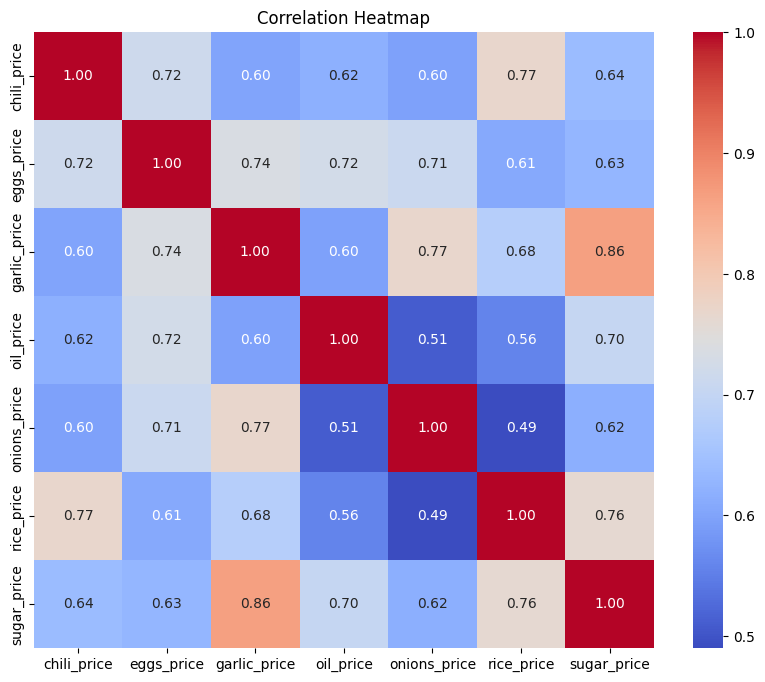

In [ ]:
corr = food_clean.drop(columns=['province', 'year']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

**Food Security Index (FSVA)**

In [ ]:
fsva = pd.concat(dfs_fsva, ignore_index=True)

In [ ]:
fsva.columns

Index(['Wilayah', 'Komposit', 'NCPR', 'Kemiskinan (%)',
       'Pengeluaran Pangan (%)', 'Tanpa Listrik (%)', 'Tanpa Air Bersih (%)',
       'Lama Sekolah Perempuan (tahun)', 'Rasio Tenaga Kesehatan',
       'Angka Harapan Hidup (tahun)', 'Stunting (%)', 'IKP', 'IKP Ranking',
       'Unnamed: 13', 'year'],
      dtype='object')

In [ ]:
fsva.rename(columns={
    'Wilayah': 'province',
    'Komposit': 'fsi',
}, inplace=True)

In [ ]:
fsva_clean = fsva[['province', 'year', 'fsi']].copy()

In [ ]:
fsva_clean['province'] = fsva_clean['province'].str.split(' - ').str[0]

In [ ]:
fsva_clean.head()

,province,year,fsi
0,aceh,2020,5
1,aceh,2020,5
2,aceh,2020,5
3,aceh,2020,5
4,aceh,2020,6


In [ ]:
fsva_clean['province'] = fsva_clean['province'].str.upper()

In [ ]:
fsva_clean['province'].unique()[:10]

array(['ACEH', 'SUMATERA UTARA', 'SUMATERA BARAT', 'RIAU', 'JAMBI',
       'SUMATERA SELATAN', 'BENGKULU', 'LAMPUNG',
       'KEPULAUAN BANGKA BELITUNG', 'KEPULAUAN RIAU'], dtype=object)

In [ ]:
fsva_clean = fsva_clean.groupby(['province', 'year'])['fsi'].mean().reset_index()

In [ ]:
fsva_clean.head()

,province,year,fsi
0,ACEH,2020,5.043478
1,ACEH,2021,5.130435
2,ACEH,2022,5.043478
3,ACEH,2023,5.260870
4,ACEH,2024,5.391304


In [ ]:
set(fsva_clean['province']) - set(food_clean['province'])

{'DI YOGYAKARTA', 'KALIMANTAN  TENGAH', 'SULAWESI  TENGGARA'}

In [ ]:
mapping = {
    'DI YOGYAKARTA': 'DAERAH ISTIMEWA YOGYAKARTA',
    'YOGYAKARTA': 'DAERAH ISTIMEWA YOGYAKARTA',
    'KALIMANTAN TENGAH': 'KALIMANTAN TENGAH',
    'SULAWESI TENGGARA': 'SULAWESI TENGGARA'
}

fsva_clean['province'] = fsva_clean['province'].replace(mapping)

In [ ]:
food_clean['province'] = food_clean['province'].str.strip()
fsva_clean['province'] = fsva_clean['province'].str.strip()

In [ ]:
set(fsva_clean['province']) - set(food_clean['province'])
set(food_clean['province']) - set(fsva_clean['province'])

{'KALIMANTAN TENGAH', 'SULAWESI TENGGARA'}

In [ ]:
for p in sorted(set(fsva_clean['province']) - set(food_clean['province'])):
    print(repr(p))

'KALIMANTAN  TENGAH'
'SULAWESI  TENGGARA'


In [ ]:
food_clean['province'] = food_clean['province'].str.replace(r'\s+', ' ', regex=True)
fsva_clean['province'] = fsva_clean['province'].str.replace(r'\s+', ' ', regex=True)

In [ ]:
set(fsva_clean['province']) - set(food_clean['province'])
set(food_clean['province']) - set(fsva_clean['province'])

set()

**Poverty Data (BPS)**

In [ ]:
bps = pd.concat(dfs_bps, ignore_index=True)

In [ ]:
bps.columns
bps.head()

,Provinsi,Garis Kemiskinan - Maret (Rp),Garis Kemiskinan - September (Rp),Jumlah Penduduk Miskin - Maret (ribu) (Ribu),Jumlah Penduduk Miskin - September (ribu) (Ribu),Persentase Penduduk Miskin - Maret,Persentase Penduduk Miskin - September,year
0,Aceh,522126,...,814.91,...,14.99,...,2020
1,Sumatera Utara,502904,...,1283.29,...,8.75,...,2020
2,Sumatera Barat,544315,...,344.23,...,6.28,...,2020
3,Riau,544057,...,483.39,...,6.82,...,2020
4,Jambi,483542,...,277.8,...,7.58,...,2020


In [ ]:
bps = bps.rename(columns={
    'Provinsi': 'province',
    'Persentase Penduduk Miskin - Maret': 'poverty_rate'
})

In [ ]:
bps = bps[['province', 'year', 'poverty_rate']]

In [ ]:
bps = bps[bps['poverty_rate'] != '...']
bps = bps[bps['poverty_rate'].notna()]

In [ ]:
bps['poverty_rate'] = bps['poverty_rate'].astype(str).str.replace(',', '.')
bps['poverty_rate'] = pd.to_numeric(bps['poverty_rate'], errors='coerce')

In [ ]:
bps['province'] = bps['province'].str.upper().str.strip()

In [ ]:
mapping = {
    'DI YOGYAKARTA': 'DAERAH ISTIMEWA YOGYAKARTA',
    'KEP. BANGKA BELITUNG': 'KEPULAUAN BANGKA BELITUNG',
    'KEP. RIAU': 'KEPULAUAN RIAU'
}

bps['province'] = bps['province'].replace(mapping)

In [ ]:
bps = bps[bps['province'] != 'INDONESIA']

In [ ]:
bps.head()

,province,year,poverty_rate
0,ACEH,2020,14.99
1,SUMATERA UTARA,2020,8.75
2,SUMATERA BARAT,2020,6.28
3,RIAU,2020,6.82
4,JAMBI,2020,7.58


In [ ]:
bps.shape
bps.isnull().sum()

,0
province,0
year,0
poverty_rate,0


In [ ]:
bps.groupby('year')['province'].nunique()

,province
year,
2020,34
2021,34
2022,34
2023,34
2024,38


In [ ]:
drop_prov = [
    'PAPUA TENGAH',
    'PAPUA PEGUNUNGAN',
    'PAPUA SELATAN',
    'PAPUA BARAT DAYA'
]

bps = bps[~bps['province'].isin(drop_prov)]

In [ ]:
bps.groupby('year')['province'].nunique()

,province
year,
2020,34
2021,34
2022,34
2023,34
2024,34


# **Data Integration**

**Merging Datasets**

In [ ]:
df = pd.merge(food_clean, fsva_clean, on=['province', 'year'])
df.head()

,province,year,chili_price,eggs_price,garlic_price,oil_price,onions_price,rice_price,sugar_price,fsi
0,ACEH,2020,33669.381944,24484.136944,30850.018472,13802.471806,37915.867083,10132.094722,14544.711250,5.043478
1,ACEH,2021,37524.022778,24937.991389,27002.886944,15761.570417,32411.769167,10014.072083,13339.820972,5.130435
2,ACEH,2022,53814.753472,27951.945833,25959.545417,20329.110972,35986.172778,10385.131111,14597.725000,5.043478
3,ACEH,2023,40037.871111,29651.360833,34584.439583,18917.544722,33875.744722,12136.644861,15368.623333,5.260870
4,ACEH,2024,47540.277639,29093.004444,39554.445139,20154.072500,37732.568472,13708.269583,18133.689167,5.391304


In [ ]:
df.shape

(170, 10)

In [ ]:
df.isnull().sum()

,0
province,0
year,0
chili_price,0
eggs_price,0
garlic_price,0
oil_price,0
onions_price,0
rice_price,0
sugar_price,0
fsi,0


In [ ]:
df[['province','year']].duplicated().sum()

np.int64(0)

In [ ]:
df_final = pd.merge(df, bps, on=['province', 'year'])

In [ ]:
df_final['year']=df_final['year'].astype(int)

# **Final Dataset Preparation**

In [ ]:
df_final[['province', 'year']].duplicated().sum()

np.int64(0)

In [ ]:
df_final['province'].nunique()

34

In [ ]:
df_final.shape

(170, 11)

In [ ]:
df_final.describe()

,year,chili_price,eggs_price,garlic_price,oil_price,onions_price,rice_price,sugar_price,fsi,poverty_rate
count,170.000000,170.000000,170.000000,170.000000,170.000000,170.000000,170.000000,170.000000,170.000000,170.000000
mean,2022.000000,47846.445236,27734.778981,34435.573082,17939.477877,36325.660400,12852.606419,15076.822017,5.089647,10.217471
std,1.418391,12996.897213,3639.944549,6708.115445,2999.691020,5963.716724,1898.650889,1694.260282,0.960034,5.130987
min,2020.000000,25539.211500,20908.951875,21067.691667,12695.194583,24294.695625,8918.510333,11380.092500,1.758621,3.780000
25%,2021.000000,37145.113452,24896.171389,29367.455938,15565.396250,32590.729427,11282.203819,14078.556406,4.900000,6.312500
50%,2022.000000,47127.312917,27635.385556,33704.357333,18342.678056,35570.464167,12910.237740,14637.037062,5.355042,8.665000
75%,2023.000000,55407.208854,30047.084792,39545.646389,19856.829138,38943.661319,13897.899948,15703.369271,5.779605,12.830000
max,2024.000000,80840.376944,37156.744167,53215.926667,26147.348542,53441.255000,18177.362833,19392.550417,6.000000,26.860000


In [ ]:
df_final.corr(numeric_only=True)

,year,chili_price,eggs_price,garlic_price,oil_price,onions_price,rice_price,sugar_price,fsi,poverty_rate
year,1.000000,0.554070,0.528292,0.551249,0.756456,0.110214,0.674623,0.727155,0.052481,-0.066207
chili_price,0.554070,1.000000,0.705577,0.542036,0.587256,0.510289,0.724317,0.589718,-0.421950,0.051744
eggs_price,0.528292,0.705577,1.000000,0.715074,0.715193,0.669838,0.570679,0.605955,-0.536408,0.322688
garlic_price,0.551249,0.542036,0.715074,1.000000,0.495133,0.686308,0.625766,0.849010,-0.340183,0.248746
oil_price,0.756456,0.587256,0.715193,0.495133,1.000000,0.374622,0.424608,0.583352,-0.190845,0.205693
onions_price,0.110214,0.510289,0.669838,0.686308,0.374622,1.000000,0.331668,0.470871,-0.647884,0.306554
rice_price,0.674623,0.724317,0.570679,0.625766,0.424608,0.331668,1.000000,0.689200,-0.196418,-0.219910
sugar_price,0.727155,0.589718,0.605955,0.849010,0.583352,0.470871,0.689200,1.000000,-0.119093,0.106490
fsi,0.052481,-0.421950,-0.536408,-0.340183,-0.190845,-0.647884,-0.196418,-0.119093,1.000000,-0.519850
poverty_rate,-0.066207,0.051744,0.322688,0.248746,0.205693,0.306554,-0.219910,0.106490,-0.519850,1.000000


In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   province      170 non-null    object 
 1   year          170 non-null    int64  
 2   chili_price   170 non-null    float64
 3   eggs_price    170 non-null    float64
 4   garlic_price  170 non-null    float64
 5   oil_price     170 non-null    float64
 6   onions_price  170 non-null    float64
 7   rice_price    170 non-null    float64
 8   sugar_price   170 non-null    float64
 9   fsi           170 non-null    float64
 10  poverty_rate  170 non-null    float64
dtypes: float64(9), int64(1), object(1)
memory usage: 14.7+ KB


In [ ]:
df_final[['egg_price','oil_price','rice_price','fsi','poverty_rate']].hist(figsize=(10,8))
plt.show()

KeyError: "['egg_price'] not in index"

In [ ]:
df_final.groupby('year')['fsi'].mean().plot(marker='o')
plt.title("Average FSI per Year")
plt.show()

In [ ]:
sns.lineplot(data=df_final, x="year", y="fsi",marker="o", errorbar=None)
plt.xticks(df_final['year'])
plt.title("Average FSI per Year")
sns.set_style("whitegrid")
plt.show()

In [ ]:
plt.scatter(df_final['poverty_rate'], df_final['fsi'])
plt.xlabel("Poverty Rate")
plt.ylabel("FSI")
plt.show()